# JAX-based Differentiable Simulation Tutorial: Detector Optimization

This tutorial demonstrates how to use JAX for optimizing detector parameters
in a physics simulation with a collimated light source.

Problem setup:
- Collimated light source along X-axis with exponential intensity decay
- Sensor at distance R=1 with adjustable position (phi_center, theta_center) and size (delta_phi, delta_theta)
- Goal: Optimize sensor size to minimize loss function

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

In [2]:
# Random key for reproducibility
key = jax.random.PRNGKey(42)

# Constants
R = 1.0  # Fixed distance to sensor
N_RAYS = 10000  # Number of rays to sample
#SENSOR_GOAL_AREA = 0.1  # Target sensor area
PHI_DECAY = 5.0  # degrees - intensity decay parameter for phi
THETA_DECAY = 10.0  # degrees - intensity decay parameter for theta

In [3]:
def spherical_to_cartesian(phi, theta, r=1.0):
    """Convert spherical coordinates to Cartesian coordinates.
    
    Args:
        phi: Azimuthal angle (0 to 2π)
        theta: Polar angle (0 to π/2 for +X hemisphere)
        r: Radial distance
    
    Returns:
        (x, y, z) coordinates
    """
    x = r * jnp.cos(phi) * jnp.sin(theta)
    y = r * jnp.sin(phi) * jnp.sin(theta)
    z = r * jnp.cos(theta)
    return x, y, z

### Define physics functions

In [4]:
def light_intensity(phi, theta):
    """Calculate light intensity based on collimated source model.
    
    Intensity decreases exponentially with opening angles from X-axis.
    
    Args:
        phi: Azimuthal angles in radians
        theta: Polar angles in radians
    
    Returns:
        Intensity weights for each ray
    """
    phi_deg = jnp.degrees(phi)
    theta_deg = jnp.degrees(theta)
    
    # Exponential decay in both phi and theta directions
    intensity = jnp.exp(-jnp.abs(phi_deg) / PHI_DECAY) * jnp.exp(-jnp.abs(theta_deg) / THETA_DECAY)
    return intensity

In [5]:
def sample_rays(key, n_rays):
    """Sample N rays uniformly in phi, theta over +X hemisphere.
    
    Args:
        key: JAX random key
        n_rays: Number of rays to sample
    
    Returns:
        phi, theta arrays for sampled rays
    """
    key1, key2 = jax.random.split(key)
    
    # Sample uniformly in phi: [-π/2, π/2] for +X hemisphere
    phi = jax.random.uniform(key1, (n_rays,), minval=-jnp.pi/2, maxval=jnp.pi/2)
    
    # Sample uniformly in cos(theta) for uniform distribution on sphere
    # theta: [0, π/2] for +X hemisphere
    cos_theta = jax.random.uniform(key2, (n_rays,), minval=0.0, maxval=1.0)
    theta = jnp.arccos(cos_theta)
    
    return phi, theta

In [6]:
def ray_intersects_sensor(ray_phi, ray_theta, sensor_phi_center, sensor_theta_center, delta_phi, delta_theta):
    """Check if rays intersect with sensor area.
    
    Args:
        ray_phi, ray_theta: Ray directions
        sensor_phi_center, sensor_theta_center: Sensor center position
        delta_phi, delta_theta: Sensor angular dimensions
    
    Returns:
        Boolean mask indicating which rays intersect the sensor
    """
    # Check if ray is within sensor angular bounds
    phi_in_range = jnp.abs(ray_phi - sensor_phi_center) <= delta_phi / 2
    theta_in_range = jnp.abs(ray_theta - sensor_theta_center) <= delta_theta / 2
    
    return phi_in_range & theta_in_range

In [7]:
def sensor_area_from_angles(delta_phi, delta_theta):
    """Calculate sensor area from angular dimensions.
    
    For small angles, solid angle ≈ delta_phi * delta_theta
    
    Args:
        delta_phi: Angular width in phi direction
        delta_theta: Angular width in theta direction
    
    Returns:
        Sensor area (solid angle)
    """
    return delta_phi * delta_theta

In [8]:
def compute_xy_distance(phi1, theta1, phi2=0.0, theta2=0.0):
    """
    Compute Euclidean distance in XY plane between two spherical points.
    Default beam at origin: phi2=0, theta2=0.
    """
    x1, y1, _ = spherical_to_cartesian(phi1, theta1)
    x2, y2, _ = spherical_to_cartesian(phi2, theta2)
    
    dx = x1 - x2
    dy = y1 - y2
    return jnp.sqrt(dx**2 + dy**2)  # squared distance in XY plane

### Compute loss function

In [9]:
@jax.jit
def compute_loss(phi_center, theta_center, ray_phi, ray_theta, ray_weights, 
                sensor_delta_phi, sensor_delta_theta, sensor_phi, sensor_theta):
    """Compute the loss function for optimization.
    
    Loss = 1/total_w + sensor_distance
    
    Args:
        phi_center, delta_center: Sensor position parameters to optimize
        ray_phi, ray_theta: Pre-sampled ray directions
        ray_weights: Pre-computed ray intensity weights
        sensor_delta_phi, sensor_delta_theta: Fixed sensor size
    
    Returns:
        Loss value
    """
    # Calculate distance to sensor
    sensor_distance = compute_xy_distance(phi_center, theta_center, sensor_phi, sensor_theta)
    
    # Find rays that intersect the sensor
    intersecting = ray_intersects_sensor(ray_phi, ray_theta, phi_center, 
                                       theta_center, sensor_delta_phi, sensor_delta_theta)
    
    print(intersecting)
    
    # Total weight of intersecting rays
    total_w = jnp.sum(ray_weights * intersecting)
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-8
    total_w = jnp.maximum(total_w, epsilon)
    
    # Loss function
    #loss = 1.0 / total_w + sensor_distance
    loss = -jnp.log(total_w + 1e-8) + 0.1 * sensor_distance
    
    return loss

### Simulate problem to solve

In [10]:
def optimize_sensor_position(sensor_phi, sensor_theta, ray_phi, ray_theta, ray_weights,
                        sensor_delta_phi, sensor_delta_theta, initial_phi_center=0.0, initial_theta_center=0.0,
                        learning_rate=0.01, n_steps=1000):
    """Optimize sensor position using gradient descent.
    
    Args:
        initial_phi_center, initial_theta_center: Initial sensor position
        ray_phi, ray_theta: Pre-sampled ray directions
        ray_weights: Pre-computed ray intensity weights
        sensor_delta_phi, sensor_delta_theta: Fixed sensor size
        learning_rate: Learning rate for gradient descent
        n_steps: Number of optimization steps
    
    Returns:
        Optimization history and final parameters
    """
    # Initialize parameters
    phi_center = initial_phi_center
    theta_center = initial_theta_center
    
    # Create gradient function
    grad_fn = jax.grad(compute_loss, argnums=(0, 1))
    
    # Storage for optimization history
    history = {
        'phi_center': [],
        'theta_center': [],
        'loss': [],
        'total_w': [],
        'sensor_distance': []
    }
    
    print(f"Optimizing sensor at position (phi={jnp.degrees(sensor_phi):.1f}°, theta={jnp.degrees(sensor_theta):.1f}°)")
    print(f"Initial: phi_center={jnp.degrees(initial_phi_center):.2f}°, theta_center={jnp.degrees(initial_theta_center):.2f}°")
    
    for step in range(n_steps):
        # Compute gradients
        grad_phi_center, grad_theta_center = grad_fn(phi_center, theta_center,  ray_phi, ray_theta, ray_weights,                       
                          sensor_delta_phi, sensor_delta_theta, sensor_phi, sensor_theta)
        '''
        def compute_loss(phi_center, theta_center, ray_phi, ray_theta, ray_weights, 
                sensor_delta_phi, sensor_delta_theta, sensor_phi, sensor_theta):

        '''
        
        # Update parameters
        phi_center -= learning_rate * grad_phi_center
        theta_center -= learning_rate * grad_theta_center
        
        # Ensure positive values
        phi_center = jnp.maximum(phi_center, 0.01)  # Minimum size constraint
        theta_center = jnp.maximum(theta_center, 0.01)
        
        # Compute current loss and metrics
        loss = compute_loss(phi_center, theta_center,  ray_phi, ray_theta, ray_weights,                
                          sensor_delta_phi, sensor_delta_theta, sensor_phi, sensor_theta)  

        # Additional metrics for monitoring
        intersecting = ray_intersects_sensor(ray_phi, ray_theta, phi_center, theta_center,
                                             sensor_delta_phi, sensor_delta_theta)
        '''
        def ray_intersects_sensor(ray_phi, ray_theta, sensor_phi_center, sensor_theta_center, delta_phi, delta_theta):
        '''
        total_w = jnp.sum(ray_weights * intersecting)
        sensor_distance = compute_xy_distance(phi_center, theta_center, sensor_phi, sensor_theta)
        '''def compute_xy_distance(phi1, theta1, phi2=0.0, theta2=0.0):'''    
        
        # Store history
        history['phi_center'].append(float(phi_center))
        history['theta_center'].append(float(theta_center))
        history['loss'].append(float(loss))
        history['total_w'].append(float(total_w))
        history['sensor_distance'].append(float(sensor_distance))
        
        # Print progress
        #if step % 100 == 0:
        #    print(f"Step {step:4d}: Loss={loss:.6f}, phi_center={jnp.degrees(phi_center):.2f}°, "
        #          f"theta_center={jnp.degrees(theta_center):.2f}°, total_w={total_w:.3f}")
    
    final_results = {
        'phi_center': float(phi_center),
        'theta_center': float(theta_center),
        'final_loss': float(loss),
        'sensor_distance': float(sensor_distance),
        'history': history
    }
    
    print(f"Final position: φ ={jnp.degrees(phi_center):.2f}°, θ ={jnp.degrees(theta_center):.2f}°, Loss={loss:.6f}")
    return final_results

`grad_fn = jax.grad(compute_loss, argnums=(0, 1))`  
Here `grad` takes a function and returns another function that computes its gradient with respect to both the first argument and the second argument of `compute_loss`.  

#### Plotting

In [11]:
def plot_optimization_results(results_list, positions_list):
    """Plot optimization results for all sensor positions."""
    fig, axes = plt.subplots(1, 5, figsize=(12, 4))
    
    colors = ['blue', 'red', 'green']
    
    # Create legend labels for all positions
    legend_labels = []
    for i, pos in enumerate(positions_list):
        legend_labels.append(f"Pos {i+1}: φ={jnp.degrees(pos[0]):.1f}°, θ={jnp.degrees(pos[1]):.1f}°")
    
    for i, (results, pos) in enumerate(zip(results_list, positions_list)):
        history = results['history']
        label = legend_labels[i]
        
        # Loss evolution
        axes[0].plot(history['loss'], color=colors[i], label=label)
        
        # Delta phi evolution
        axes[1].plot(np.degrees(history['phi_center']), color=colors[i], label=label)
        
        # Delta theta evolution
        axes[2].plot(np.degrees(history['theta_center']), color=colors[i], label=label)
        
        # Total weight evolution
        axes[3].plot(history['total_w'], color=colors[i], label=label)
        
        # Sensor area vs goal
        axes[4].plot(history['sensor_distance'], color=colors[i], label=label)
    
    # Configure axes
    axes[0].set_ylabel('Loss')
    axes[0].set_xlabel('Iteration')
    axes[0].set_title('Loss Evolution')
    axes[0].set_yscale('log')
    
    axes[1].set_ylabel('φ (degrees)')
    axes[1].set_xlabel('Iteration')
    axes[1].set_title('φ Evolution')
    
    axes[2].set_ylabel('θ (degrees)')
    axes[2].set_xlabel('Iteration')
    axes[2].set_title('θ Evolution')
    
    axes[3].set_ylabel('Total Weight')
    axes[3].set_xlabel('Iteration')
    axes[3].set_title('Collected Light Weight')
    
    axes[4].axhline(y=0, color='black', linestyle=':')
    axes[4].set_ylabel('Distance to Sensor')
    axes[4].set_xlabel('Iteration')
    axes[4].set_title('Distance to Sensor vs Target')
    #axes[4].set_ylim(0, SENSOR_GOAL_AREA*1.2)
    
    # Create a single legend at the top center
    fig.legend(legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.8)  # Make room for the legend
    plt.savefig('optimization_results.png', dpi=150, bbox_inches='tight')
    plt.show()

## Run sim

=== JAX-based Differentiable Simulation Tutorial ===
Optimizing detector position for collimated light source

Sampling 10000 rays...
Total sampled light intensity: 14.427
Average ray weight: 0.001443


OPTIMIZATION 1/3
Optimizing sensor at position (phi=40.0°, theta=20.0°)
Initial: phi_center=-0.02°, theta_center=1.69°
JitTracer<bool[10000]>
Final position: φ =40.00°, θ =19.91°, Loss=5.803593

OPTIMIZATION 2/3
Optimizing sensor at position (phi=15.0°, theta=30.0°)
Initial: phi_center=-3.35°, theta_center=0.96°
Final position: φ =15.00°, θ =30.17°, Loss=1.680919

OPTIMIZATION 3/3
Optimizing sensor at position (phi=35.0°, theta=60.0°)
Initial: phi_center=0.81°, theta_center=2.21°
Final position: φ =34.80°, θ =60.00°, Loss=7.975020


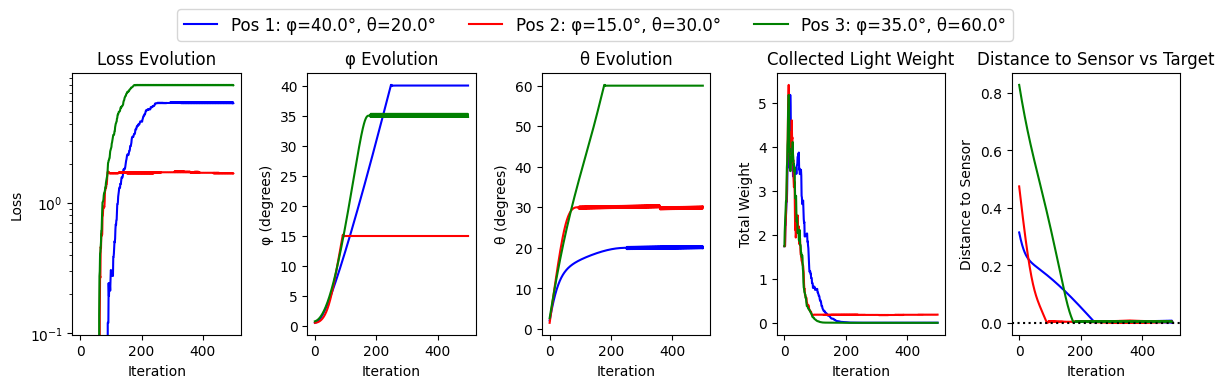

Optimization complete! Results saved to 'optimization_results.png'


In [12]:
"""Main function to run the optimization tutorial."""
print("=== JAX-based Differentiable Simulation Tutorial ===")
print("Optimizing detector position for collimated light source\n")

# Sample rays once for all optimizations
print(f"Sampling {N_RAYS} rays...")
ray_phi, ray_theta = sample_rays(key, N_RAYS)
ray_weights = light_intensity(ray_phi, ray_theta)

print(f"Total sampled light intensity: {jnp.sum(ray_weights):.3f}")
print(f"Average ray weight: {jnp.mean(ray_weights):.6f}\n")

# Define 3 different sensor positions for optimization
sensor_positions = [
    (jnp.radians(40), jnp.radians(20)),      # φ=0°, θ=30°
    (jnp.radians(15), jnp.radians(30)),     # φ=15°, θ=45°
    (jnp.radians(35), jnp.radians(60))     # φ=-20°, θ=60°
]

results_list = []

# Run optimization for each sensor position
for i, (phi_center, theta_center) in enumerate(sensor_positions):
    print(f"\n{'='*50}")
    print(f"OPTIMIZATION {i+1}/3")
    print(f"{'='*50}")
    
    results = optimize_sensor_position(
        phi_center, theta_center, ray_phi, ray_theta, ray_weights,
        sensor_delta_phi=0.2, sensor_delta_theta=0.2, 
        initial_phi_center=jnp.radians(np.random.uniform(-5, 5)),   # Start around phi=0°
        initial_theta_center=jnp.radians(np.random.uniform(-5, 5)),  # Start around theta=0°
        learning_rate=0.1, n_steps=500
    )
    '''
    def optimize_sensor_position(sensor_phi, sensor_theta, ray_phi, ray_theta, ray_weights,
                        sensor_delta_phi, sensor_delta_theta, initial_phi_center=0.0, initial_theta_center=0.0,
                        learning_rate=0.01, n_steps=1000):
    '''
    
    results_list.append(results)

# Plot results
'''
print(f"\n{'='*50}")
print("SUMMARY OF RESULTS")
print(f"{'='*50}")

for i, (results, pos) in enumerate(zip(results_list, sensor_positions)):
    print(f"Position {i+1} (φ={jnp.degrees(pos[0]):.1f}°, θ={jnp.degrees(pos[1]):.1f}°):")
    print(f"  Optimal φ = {jnp.degrees(results['phi_center']):.2f}°")
    print(f"  Optimal θ = {jnp.degrees(results['theta_center']):.2f}°")
    print(f"  Final loss = {results['final_loss']:.6f}")
    print(f"  Final distance = {results['history']['sensor_distance'][-1]:.4f}")
    print()
'''
# Create visualization
plot_optimization_results(results_list, sensor_positions)

print("Optimization complete! Results saved to 'optimization_results.png'")